<a href="https://colab.research.google.com/github/vabhavmehta27/Car-Price-Prediction---ML-Project/blob/main/Car_Prize_Pridiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('car_prediction_data.csv')

#1. Display Top 10 Rows of The Dataset

In [4]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


#2. Check Last 10 Rows of The Dataset

In [5]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


#3. Find Shape of Our Dataset (Number of Rows And Number of Columns)

In [6]:
data.shape

(301, 9)

In [7]:
print('Number of Rows',data.shape[0])
print('Number of Columns',data.shape[1])

Number of Rows 301
Number of Columns 9


#4. Getting Information About Our Dataset Like Total Number Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirement

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


#5. Check Null Values In The Dataset

In [9]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


#6. Get Overall Statistics About The DataFrame

In [10]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


#7. Data Preprocessing

In [11]:
data.head(1)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0


In [12]:
import datetime

In [13]:
date_time = datetime.datetime.now()

In [14]:
data['Age']=date_time.year - data['Year']

In [15]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [16]:
data.drop('Year',axis=1,inplace=True)

In [17]:
data.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


#Outlier Remover

In [18]:
import seaborn as sns

<Axes: ylabel='Selling_Price'>

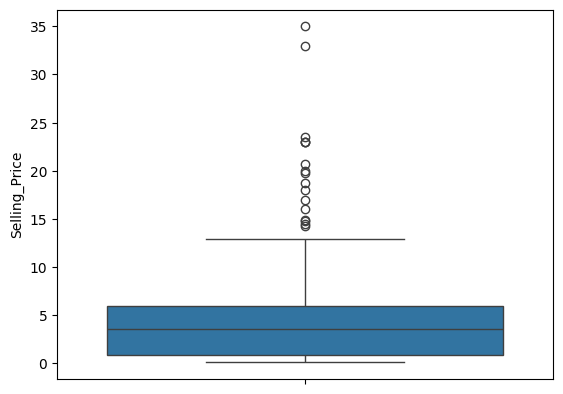

In [19]:
sns.boxplot(data['Selling_Price'])

In [20]:
sorted(data['Selling_Price'],reverse=True)

[35.0,
 33.0,
 23.5,
 23.0,
 23.0,
 23.0,
 20.75,
 19.99,
 19.75,
 18.75,
 18.0,
 17.0,
 16.0,
 14.9,
 14.73,
 14.5,
 14.25,
 12.9,
 12.5,
 11.75,
 11.5,
 11.45,
 11.25,
 11.25,
 11.25,
 10.9,
 10.25,
 10.11,
 9.7,
 9.65,
 9.5,
 9.25,
 9.25,
 9.25,
 9.15,
 9.1,
 8.99,
 8.75,
 8.65,
 8.55,
 8.5,
 8.4,
 8.4,
 8.35,
 8.25,
 8.25,
 7.9,
 7.75,
 7.75,
 7.75,
 7.5,
 7.5,
 7.5,
 7.45,
 7.45,
 7.45,
 7.4,
 7.25,
 7.25,
 7.2,
 7.05,
 6.95,
 6.85,
 6.75,
 6.7,
 6.6,
 6.5,
 6.5,
 6.45,
 6.4,
 6.25,
 6.25,
 6.15,
 6.1,
 6.0,
 6.0,
 6.0,
 6.0,
 5.95,
 5.95,
 5.9,
 5.85,
 5.85,
 5.8,
 5.75,
 5.75,
 5.65,
 5.5,
 5.5,
 5.5,
 5.5,
 5.5,
 5.4,
 5.4,
 5.35,
 5.3,
 5.3,
 5.25,
 5.25,
 5.25,
 5.25,
 5.25,
 5.25,
 5.25,
 5.2,
 5.15,
 5.11,
 5.0,
 4.95,
 4.95,
 4.9,
 4.9,
 4.85,
 4.8,
 4.8,
 4.75,
 4.75,
 4.75,
 4.75,
 4.75,
 4.75,
 4.65,
 4.6,
 4.5,
 4.5,
 4.5,
 4.5,
 4.5,
 4.5,
 4.5,
 4.4,
 4.4,
 4.4,
 4.35,
 4.15,
 4.1,
 4.1,
 4.0,
 4.0,
 4.0,
 4.0,
 4.0,
 3.95,
 3.95,
 3.9,
 3.9,
 3.8,
 3.75,
 3.75,
 3.6

In [21]:
data = data[~(data['Selling_Price']>=33.0) & (data['Selling_Price']<=35.0)]
data

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [22]:
data.shape

(299, 9)

#Encoding the Categorical Columns

In [23]:
data.head(1)

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12


In [24]:
data['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [25]:
data['Fuel_Type'] = data['Fuel_Type'].map({'Petrol':0,'Diesel':1,'CNG':2})

In [26]:
data['Fuel_Type'].unique()

array([0, 1, 2])

In [27]:
data['Seller_Type'].unique()

array(['Dealer', 'Individual'], dtype=object)

In [28]:
data['Seller_Type'] = data['Seller_Type'].map({'Dealer':0,'Individual':1})

In [29]:
data['Seller_Type'].unique()

array([0, 1])

In [30]:
data['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [31]:
data['Transmission'] =data['Transmission'].map({'Manual':0,'Automatic':1})

In [32]:
data['Transmission'].unique()

array([0, 1])

In [33]:
data.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,0,0,0,0,12
1,sx4,4.75,9.54,43000,1,0,0,0,13
2,ciaz,7.25,9.85,6900,0,0,0,0,9
3,wagon r,2.85,4.15,5200,0,0,0,0,15
4,swift,4.60,6.87,42450,1,0,0,0,12


#8. Store Feature Matrix In X and Response(Target) In Vector y

In [34]:
X = data.drop(['Car_Name','Selling_Price'],axis=1)
y = data['Selling_Price']

In [35]:
y

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60
...,...
296,9.50
297,4.00
298,3.35
299,11.50


#9. Splitting The Dataset Into The Training Set And Test Set

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

#10. Import The models

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

#11. Model Training

In [39]:
lr = LinearRegression()
lr.fit(X_train,y_train)

rf = RandomForestRegressor()
rf.fit(X_train,y_train)

xgb = GradientBoostingRegressor()
xgb.fit(X_train,y_train)

xg = XGBRegressor()
xg.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#12. Prediction on Test Data

In [40]:
y_pred1 = lr.predict(X_test)
y_pred2 = rf.predict(X_test)
y_pred3 = xgb.predict(X_test)
y_pred4 = xg.predict(X_test)

#13. Evaluating the Algorithm

In [41]:
from sklearn import metrics

In [42]:
score1 = metrics.r2_score(y_test,y_pred1)
score2 = metrics.r2_score(y_test,y_pred2)
score3 = metrics.r2_score(y_test,y_pred3)
score4 = metrics.r2_score(y_test,y_pred4)

In [43]:
print(score1,score2,score3,score4)

0.6790884983129405 0.7262882463850032 0.8811820710999698 0.8887471822279068


In [44]:
final_data = pd.DataFrame({'Models':['LR','RF','GBR','XG'],
             "R2_SCORE":[score1,score2,score3,score4]})

In [45]:
final_data

,Models,R2_SCORE
0,LR,0.679088
1,RF,0.726288
2,GBR,0.881182
3,XG,0.888747


<Axes: xlabel='Models', ylabel='R2_SCORE'>

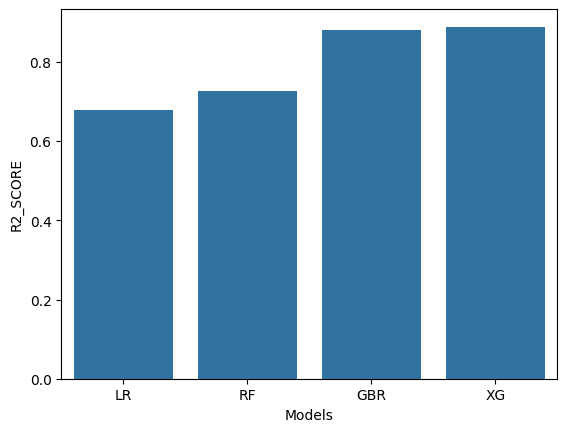

In [46]:
sns.barplot(x=final_data['Models'],y=final_data['R2_SCORE'])

#14. Save The Model

In [47]:
xg = XGBRegressor()
xg_final = xg.fit(X,y)

In [48]:
import joblib

In [49]:
joblib.dump(xg_final,'car_price_predictor')

['car_price_predictor']

In [50]:
model = joblib.load('car_price_predictor')

#15. Prediction on New Data

In [51]:
import pandas as pd
data_new = pd.DataFrame({
    'Present_Price':5.59,
    'Kms_Driven':27000,
    'Fuel_Type':0,
    'Seller_Type':0,
    'Transmission':0,
    'Owner':0,
    'Age':8
},index=[0])

In [52]:
model.predict(data_new)

array([3.630374], dtype=float32)

#GUI

In [53]:
import pandas as pd
import joblib
from IPython.display import display
import ipywidgets as widgets

model = joblib.load('car_price_predictor')

present_price = widgets.FloatText(description='Present Price:')
kms_driven = widgets.FloatText(description='Kms Driven:')
fuel_type = widgets.FloatText(description='Fuel Type:')
seller_type = widgets.FloatText(description='Seller Type:')
transmission = widgets.FloatText(description='Transmission:')
owner = widgets.FloatText(description='Owner:')
age = widgets.FloatText(description='Age:')

output = widgets.Output()

def predict(_):
    p1 = present_price.value
    p2 = kms_driven.value
    p3 = fuel_type.value
    p4 = seller_type.value
    p5 = transmission.value
    p6 = owner.value
    p7 = age.value

    data_new = pd.DataFrame({
        'Present_Price': [p1],
        'Kms_Driven': [p2],
        'Fuel_Type': [p3],
        'Seller_Type': [p4],
        'Transmission': [p5],
        'Owner': [p6],
        'Age': [p7]
    })

    result = model.predict(data_new)
    with output:
        output.clear_output()
        print(f"Predicted Car Price: {result[0]}")

predict_button = widgets.Button(description='Predict')
predict_button.on_click(predict)

display(present_price, kms_driven, fuel_type, seller_type, transmission, owner, age, predict_button, output)



FloatText(value=0.0, description='Present Price:')

FloatText(value=0.0, description='Kms Driven:')

FloatText(value=0.0, description='Fuel Type:')

FloatText(value=0.0, description='Seller Type:')

FloatText(value=0.0, description='Transmission:')

FloatText(value=0.0, description='Owner:')

FloatText(value=0.0, description='Age:')

Button(description='Predict', style=ButtonStyle())

Output()